# Digest2 / VDP Four-Case Smoothing Comparison

This notebook separates two effects that changed at the same time:

- the observation date / sky-center geometry
- the NEO density-map smoothing recipe

The target comparison grid is:

| Case | Date / geometry | Smoothing |
| --- | --- | --- |
| March 21 old smoothing | 2025-03-21, center=(180, 0) | old map recipe |
| March 21 new smoothing | 2025-03-21, center=(180, 0) | current NEO smoothing |
| May 9 old smoothing | 2026-05-09T22, center=(229, 0) | old map recipe |
| May 9 new smoothing | 2026-05-09T22, center=(229, 0) | current NEO smoothing |

Each case should point to a scored parquet with at least these columns: `true_population`, `P_NEO_vdp`, and `P_NEO_d2`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != 'neomod' and (HERE / 'neomod').exists():
    HERE = HERE / 'neomod'

plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 180

THRESHOLDS = np.linspace(0.0, 1.0, 201)

## 1. Register the Four Cases

The notebook will run with whatever parquets exist. Missing paths are reported instead of causing the analysis to fail.

In [2]:
CASES = [
    {
        'case': 'March 21 old smoothing',
        'short': 'Mar21 old',
        'date_group': '2025-03-21',
        'smoothing_group': 'old smoothing',
        'path': HERE / 's3m_digest2_comparison.parquet',
    },
    {
        'case': 'March 21 new smoothing',
        'short': 'Mar21 new',
        'date_group': '2025-03-21',
        'smoothing_group': 'new smoothing',
        'path': HERE / 's3m_digest2_comparison_2025-03-21_new_smoothing.parquet',
    },
    {
        'case': 'May 9 old smoothing',
        'short': 'May9 old',
        'date_group': '2026-05-09T22',
        'smoothing_group': 'old smoothing',
        'path': HERE / 's3m_digest2_comparison_2026-05-09T22_old_smoothing.parquet',
    },
    {
        'case': 'May 9 new smoothing',
        'short': 'May9 new',
        'date_group': '2026-05-09T22',
        'smoothing_group': 'new smoothing',
        'path': HERE / 's3m_digest2_comparison_2026-05-09T22_neocp.parquet',
    },
]

case_table = pd.DataFrame([
    {
        'case': c['case'],
        'path': c['path'].name,
        'exists': c['path'].exists(),
    }
    for c in CASES
])
case_table

,case,path,exists
0,March 21 old smoothing,s3m_digest2_comparison.parquet,True
1,March 21 new smoothing,s3m_digest2_comparison_2025-03-21_new_smoothin...,False
2,May 9 old smoothing,s3m_digest2_comparison_2026-05-09T22_old_smoot...,False
3,May 9 new smoothing,s3m_digest2_comparison_2026-05-09T22_neocp.par...,True


## 2. Helpers

`completeness` is true-positive recovery among true NEOs. `contamination` is false positives divided by all selected objects. Lower contamination means the selected follow-up list is cleaner.

In [3]:
def compute_roc(scores, is_neo, thresholds=THRESHOLDS):
    scores = np.asarray(scores, dtype=float)
    is_neo = np.asarray(is_neo, dtype=bool)
    n_neo = is_neo.sum()
    comp = np.empty(len(thresholds))
    cont = np.empty(len(thresholds))

    for j, t in enumerate(thresholds):
        selected = scores > t
        tp = selected[is_neo].sum()
        fp = selected[~is_neo].sum()
        comp[j] = tp / max(n_neo, 1)
        cont[j] = fp / max(tp + fp, 1)
    return comp, cont


def best_f1(comp, cont, thresholds=THRESHOLDS):
    purity = 1.0 - cont
    f1 = np.where(purity + comp > 0, 2 * purity * comp / (purity + comp + 1e-12), 0.0)
    i = int(np.argmax(f1))
    return {
        'threshold': float(thresholds[i]),
        'completeness': float(comp[i]),
        'contamination': float(cont[i]),
        'purity': float(purity[i]),
        'f1': float(f1[i]),
    }


def load_case(case):
    path = case['path']
    if not path.exists():
        return None

    df = pd.read_parquet(path)
    required = {'true_population', 'P_NEO_vdp', 'P_NEO_d2'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'{path.name} is missing required columns: {sorted(missing)}')

    is_neo = (df['true_population'] == 'NEO').to_numpy()
    comp_vdp, cont_vdp = compute_roc(df['P_NEO_vdp'], is_neo)
    comp_d2, cont_d2 = compute_roc(df['P_NEO_d2'], is_neo)

    out = dict(case)
    out['df'] = df
    out['is_neo'] = is_neo
    out['roc'] = {
        'VDP': {'completeness': comp_vdp, 'contamination': cont_vdp, **best_f1(comp_vdp, cont_vdp)},
        'digest2': {'completeness': comp_d2, 'contamination': cont_d2, **best_f1(comp_d2, cont_d2)},
    }
    return out


loaded_cases = [c for c in (load_case(case) for case in CASES) if c is not None]
missing_cases = [case for case in CASES if not case['path'].exists()]

print(f'Loaded {len(loaded_cases)} case(s).')
if missing_cases:
    print('Missing case parquet(s):')
    for case in missing_cases:
        print(f"  - {case['case']}: {case['path'].name}")

Loaded 2 case(s).
Missing case parquet(s):
  - March 21 new smoothing: s3m_digest2_comparison_2025-03-21_new_smoothing.parquet
  - May 9 old smoothing: s3m_digest2_comparison_2026-05-09T22_old_smoothing.parquet


## 3. Summary Table

This table reports the best-F1 operating point for each classifier in each loaded case.

In [4]:
rows = []
for case in loaded_cases:
    df = case['df']
    counts = df['true_population'].value_counts()
    for classifier in ['VDP', 'digest2']:
        stats = case['roc'][classifier]
        rows.append({
            'case': case['case'],
            'date_group': case['date_group'],
            'smoothing_group': case['smoothing_group'],
            'classifier': classifier,
            'n_total': len(df),
            'n_neo': int(counts.get('NEO', 0)),
            'n_non_neo': int(len(df) - counts.get('NEO', 0)),
            'threshold': stats['threshold'],
            'completeness': stats['completeness'],
            'contamination': stats['contamination'],
            'purity': stats['purity'],
            'f1': stats['f1'],
        })

summary = pd.DataFrame(rows)
display_cols = ['case', 'classifier', 'n_total', 'n_neo', 'threshold', 'completeness', 'contamination', 'purity', 'f1']
summary[display_cols].style.format({
    'threshold': '{:.3f}',
    'completeness': '{:.1%}',
    'contamination': '{:.1%}',
    'purity': '{:.1%}',
    'f1': '{:.3f}',
})

,case,classifier,n_total,n_neo,threshold,completeness,contamination,purity,f1
0,March 21 old smoothing,VDP,38045,2233,0.005,78.3%,5.7%,94.3%,0.856
1,March 21 old smoothing,digest2,38045,2233,0.970,51.5%,6.2%,93.8%,0.665
2,May 9 new smoothing,VDP,21027,1119,0.030,75.0%,2.7%,97.3%,0.847
3,May 9 new smoothing,digest2,21027,1119,0.960,52.1%,11.9%,88.1%,0.655


## 4. Best-F1 Metrics by Case

Use this plot to see whether the main change is recovery (`completeness`) or list cleanliness (`contamination` / `purity`).

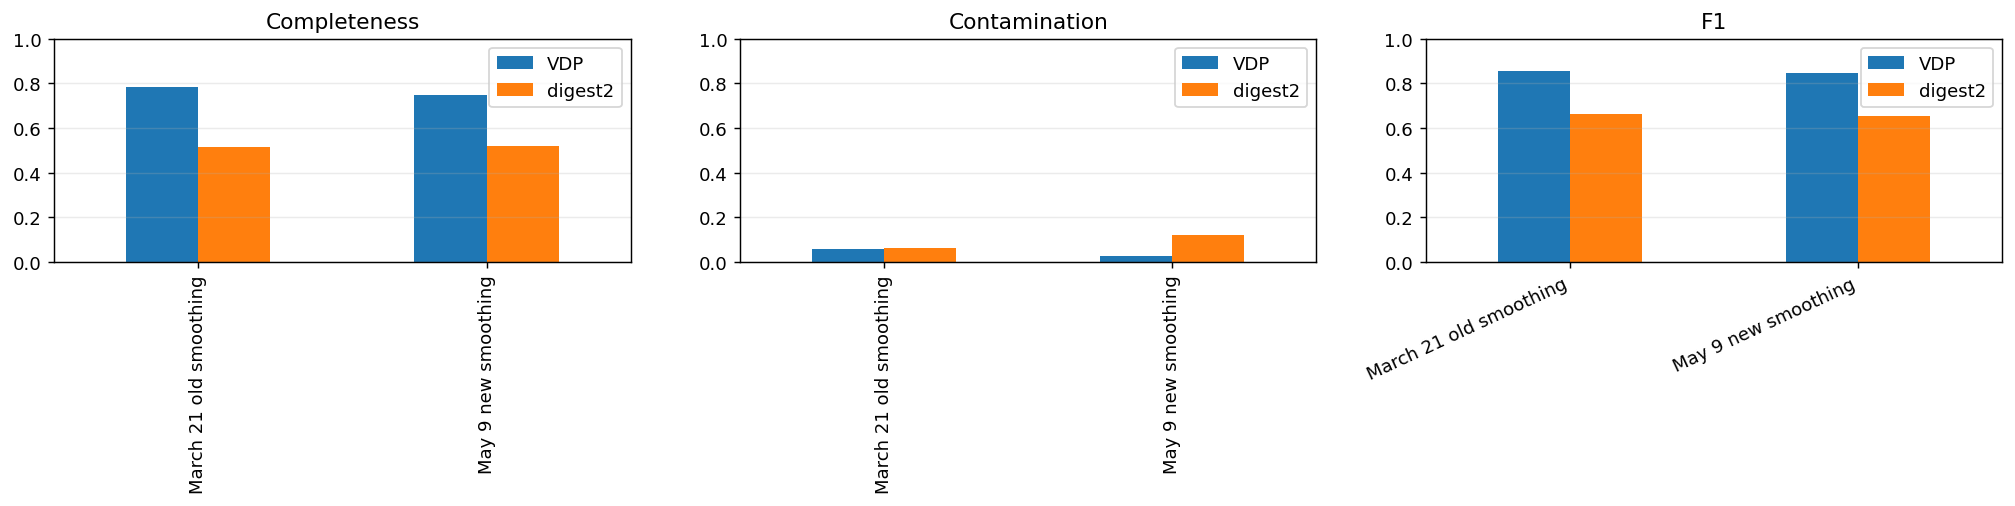

In [5]:
if summary.empty:
    raise RuntimeError('No case parquets were loaded.')

metric_names = ['completeness', 'contamination', 'f1']
fig, axes = plt.subplots(1, len(metric_names), figsize=(5.2 * len(metric_names), 4), sharex=True)

for ax, metric in zip(axes, metric_names):
    pivot = summary.pivot(index='case', columns='classifier', values=metric).reindex([c['case'] for c in loaded_cases])
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='best')

plt.xticks(rotation=25, ha='right')
plt.tight_layout()

## 5. ROC Curves

The left panel is VDP; the right panel is digest2. If the date changes the object mixture, both classifiers can move. If smoothing mostly changes the VDP map, the VDP panel should move more than digest2.

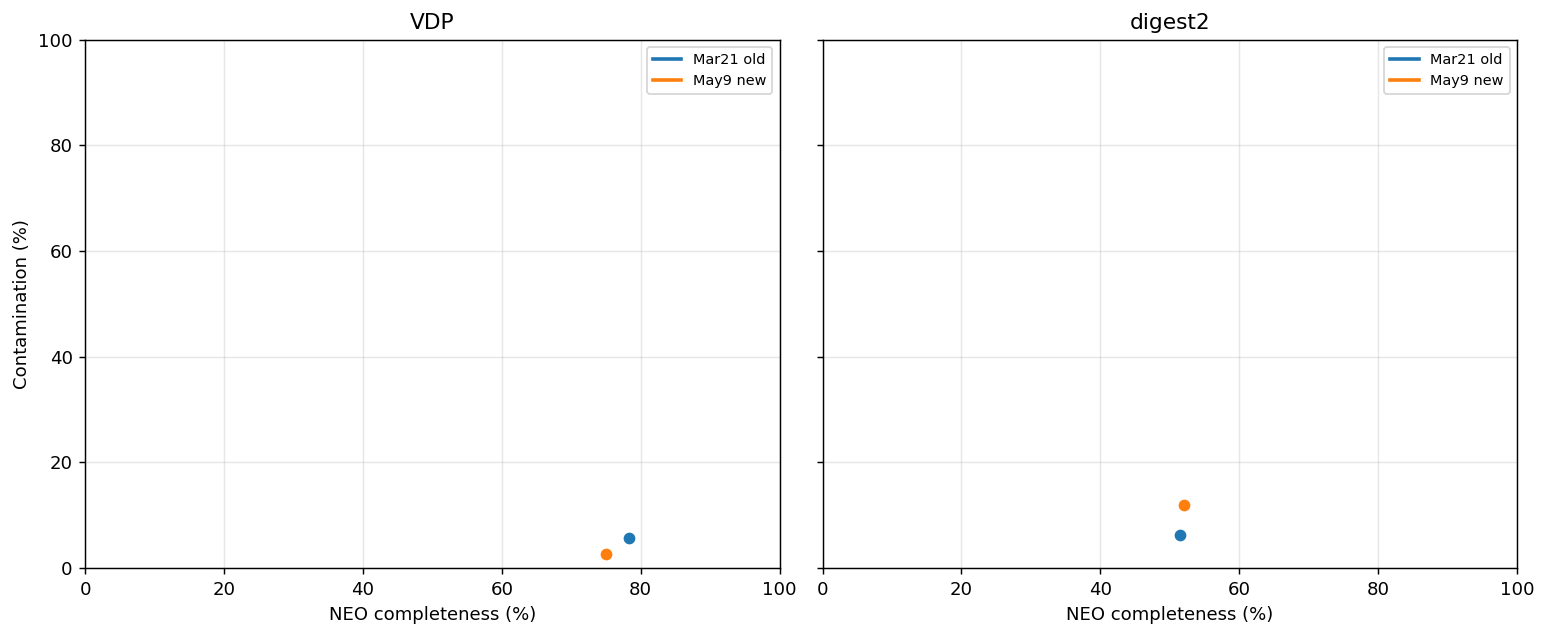

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, classifier in zip(axes, ['VDP', 'digest2']):
    for case in loaded_cases:
        roc = case['roc'][classifier]
        ax.plot(roc['completeness'] * 100, roc['contamination'] * 100, lw=2, label=case['short'])
        ax.scatter([roc['completeness'] * 100], [roc['contamination'] * 100], s=30)
    ax.set_title(classifier)
    ax.set_xlabel('NEO completeness (%)')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Contamination (%)')
plt.tight_layout()

## 6. Threshold Curves

This view makes it easier to see if a new map changed the best operating threshold, not just the best-F1 metric.

ValueError: x and y must have same first dimension, but have shapes (201,) and (1,)

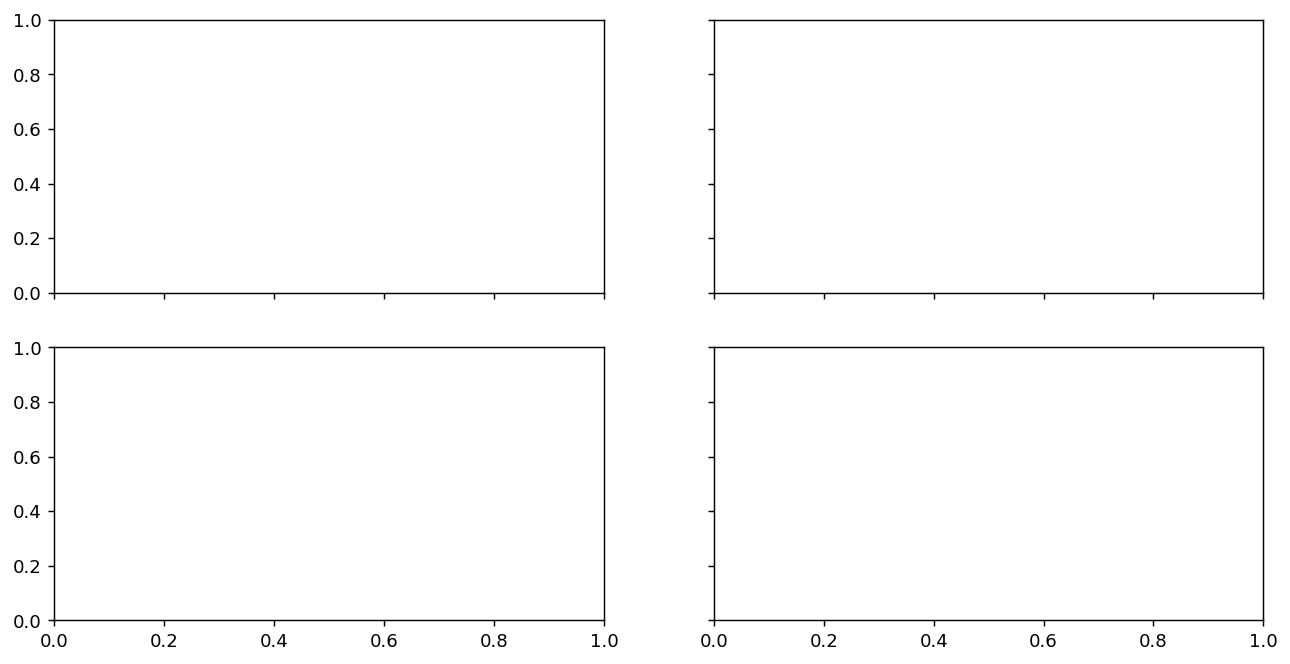

In [7]:
fig, axes = plt.subplots(len(loaded_cases), 2, figsize=(12, max(3.2, 3.0 * len(loaded_cases))), sharex=True, sharey=True)
if len(loaded_cases) == 1:
    axes = np.asarray([axes])

for row, case in enumerate(loaded_cases):
    for col, classifier in enumerate(['VDP', 'digest2']):
        ax = axes[row, col]
        roc = case['roc'][classifier]
        ax.plot(THRESHOLDS, roc['completeness'] * 100, label='completeness')
        ax.plot(THRESHOLDS, roc['contamination'] * 100, label='contamination')
        ax.axvline(roc['threshold'], color='k', lw=1, alpha=0.5)
        ax.set_title(f"{case['short']} — {classifier}, best t={roc['threshold']:.3f}")
        ax.grid(alpha=0.25)
        ax.set_ylim(0, 100)
        if row == len(loaded_cases) - 1:
            ax.set_xlabel('score threshold')
        if col == 0:
            ax.set_ylabel('%')
        ax.legend(fontsize=8)

plt.tight_layout()

## 7. Pairwise Deltas

Once all four parquets exist, these deltas answer two different questions:

- same date, old vs new smoothing: smoothing effect
- same smoothing, March vs May: geometry/date effect

In [ ]:
def row_for(case_name, classifier):
    hit = summary[(summary['case'] == case_name) & (summary['classifier'] == classifier)]
    if hit.empty:
        return None
    return hit.iloc[0]


comparisons = [
    ('March smoothing effect', 'March 21 old smoothing', 'March 21 new smoothing'),
    ('May smoothing effect', 'May 9 old smoothing', 'May 9 new smoothing'),
    ('Old-smoothing date effect', 'March 21 old smoothing', 'May 9 old smoothing'),
    ('New-smoothing date effect', 'March 21 new smoothing', 'May 9 new smoothing'),
]

delta_rows = []
for label, base_case, compare_case in comparisons:
    for classifier in ['VDP', 'digest2']:
        base = row_for(base_case, classifier)
        comp = row_for(compare_case, classifier)
        if base is None or comp is None:
            continue
        delta_rows.append({
            'comparison': label,
            'classifier': classifier,
            'from': base_case,
            'to': compare_case,
            'delta_completeness': comp['completeness'] - base['completeness'],
            'delta_contamination': comp['contamination'] - base['contamination'],
            'delta_f1': comp['f1'] - base['f1'],
        })

delta = pd.DataFrame(delta_rows)
if delta.empty:
    print('No complete pairwise deltas yet. Add the missing case parquets above, then rerun.')
else:
    display(delta.style.format({
        'delta_completeness': '{:+.1%}',
        'delta_contamination': '{:+.1%}',
        'delta_f1': '{:+.3f}',
    }))

## 8. Score Distributions by True Population

These histograms help explain why contamination changes. If non-NEOs move away from high VDP scores, contamination drops even if completeness changes only modestly.

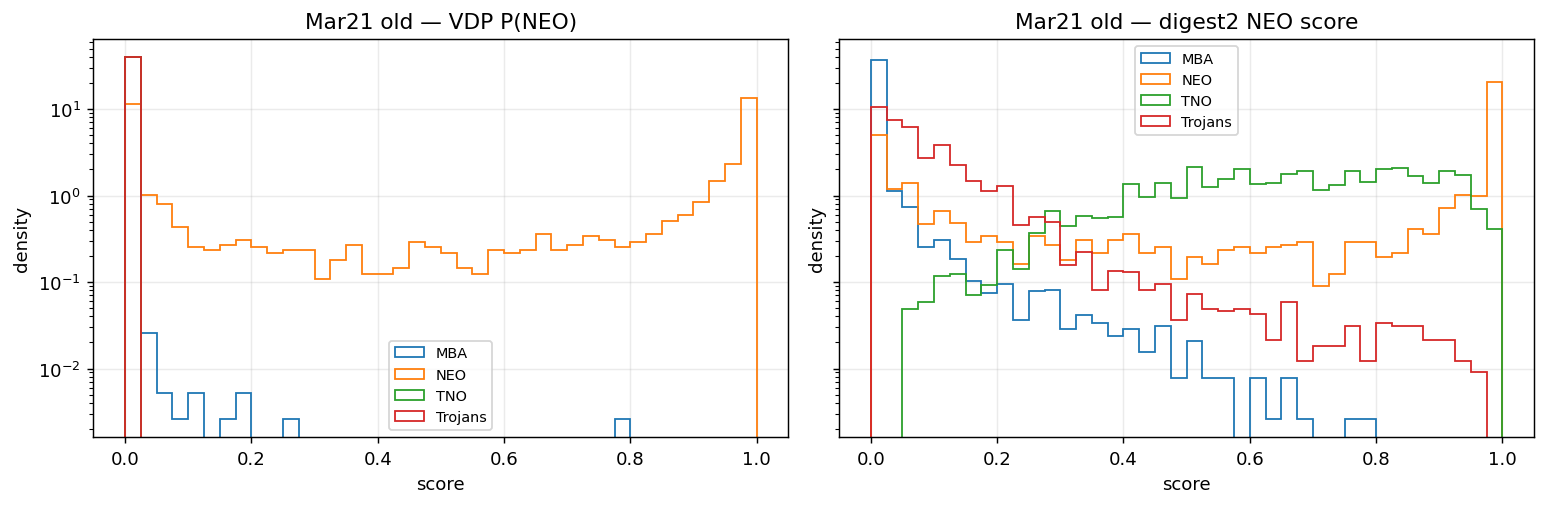

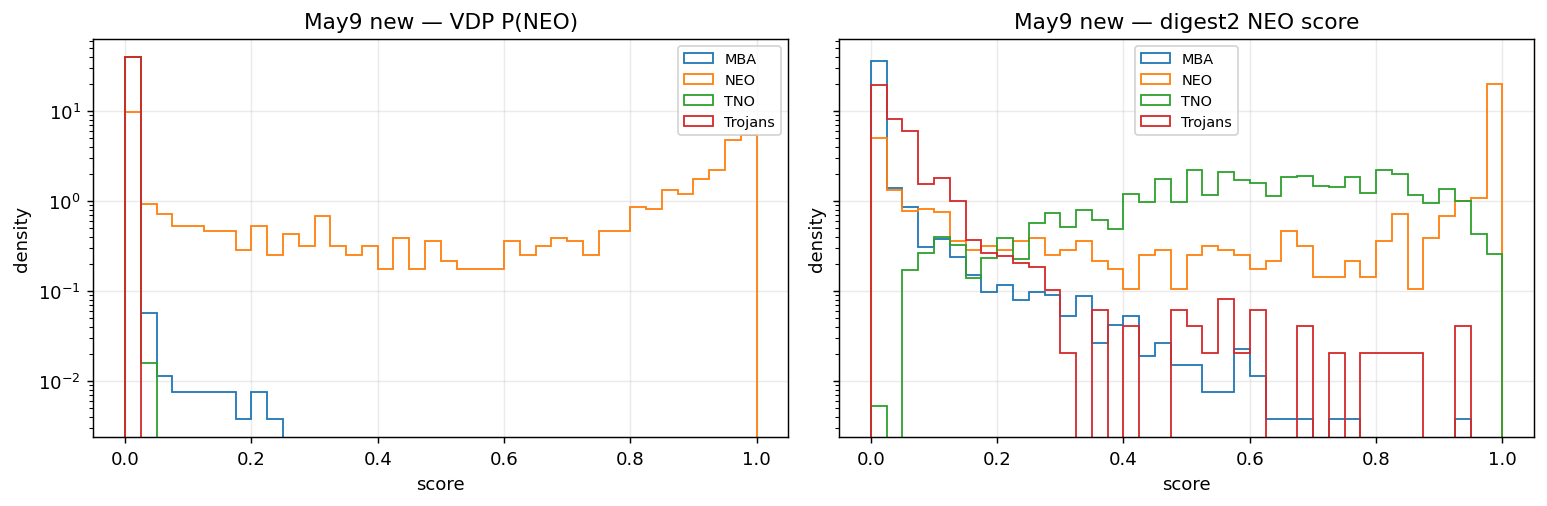

In [8]:
for case in loaded_cases:
    df = case['df'].copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, score_col, title in zip(axes, ['P_NEO_vdp', 'P_NEO_d2'], ['VDP P(NEO)', 'digest2 NEO score']):
        for pop, group in df.groupby('true_population'):
            ax.hist(group[score_col], bins=np.linspace(0, 1, 41), histtype='step', density=True, lw=1.5, label=pop)
        ax.set_title(f"{case['short']} — {title}")
        ax.set_xlabel('score')
        ax.set_ylabel('density')
        ax.set_yscale('log')
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. Notes for Filling Missing Cases

If a case is missing, generate or restore the matching probability map first, then run `run_digest2_comparison.py` with a unique `RUN_LABEL` so the output parquet name matches the case path above.

For example, the current May 9 smoothed case is already:

```text
s3m_digest2_comparison_2026-05-09T22_neocp.parquet
```

The old-smoothing cases require old-smoothing probability maps. A scored parquet alone cannot reconstruct the old VDP probabilities if the old map was not saved.